In [1]:
import numpy as np
import matplotlib.pyplot as plt

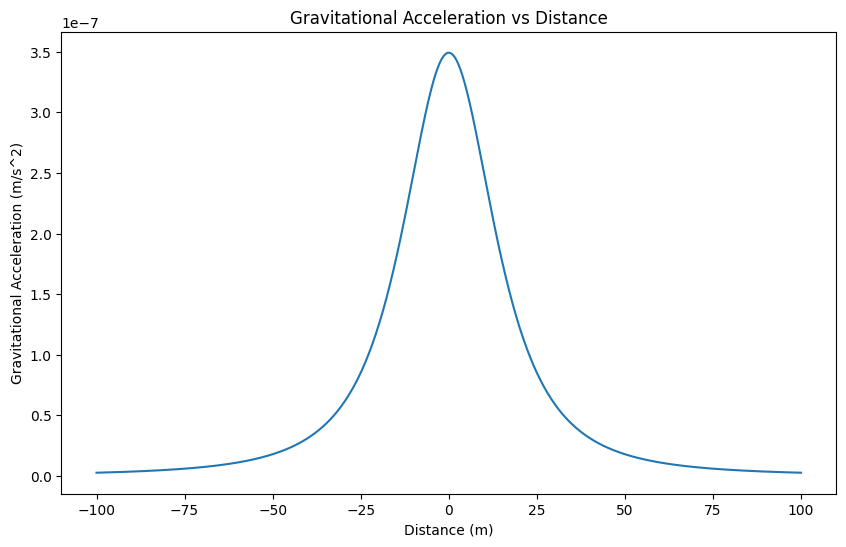

In [21]:
x=np.linspace(-100,100,1000)
z=20

gamma=6.67*10**-11
rho=500
R=10

k=(4*np.pi*R**3*gamma*rho)/3

g=(k*z)/((x**2+z**2)**1.5)


plt.figure(figsize=(10,6))
plt.plot(x, g)
plt.title('Gravitational Acceleration vs Distance')
plt.xlabel('Distance (m)')
plt.ylabel('Gravitational Acceleration (m/s^2)')

plt.show()

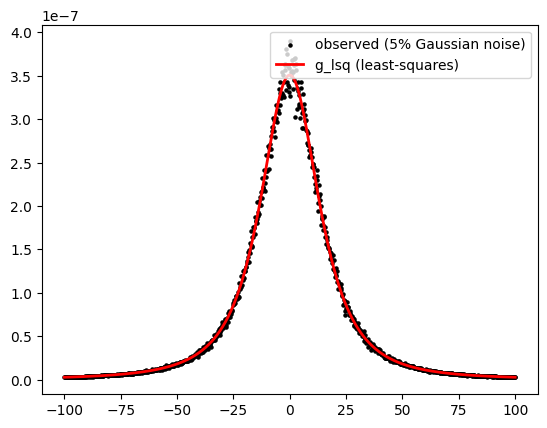

In [25]:
# Add 5% Gaussian noise to generate observed g (g_obs)
noise = np.random.normal(0, 0.05, size=g.shape)
g_obs = g * (1 + noise)

# Linear least-squares inversion to estimate k and compute g_lsq
G = z / (x**2 + z**2)**1.5
G = G[:, np.newaxis]
k_lsq, _, _, _ = np.linalg.lstsq(G, g_obs, rcond=None)
g_lsq = G @ k_lsq

plt.scatter(x, g_obs, color='black', s=5, label='observed (5% Gaussian noise)')
plt.plot(x, g_lsq, color='red', linewidth=2, label='g_lsq (least-squares)')
plt.legend()
